### For the Machine Learning course
### Arta Khosravi
### July 2025

<div dir="rtl">
برای این پروژه ما اطلاعات تقریبا ۴۰۰۰ آپارتمان در تهران را تهیه کرده ایم. تمامی داده ها کاملا واقعی هستند. وظیفه شما این است که با استفاده از ویژگی های دیتاست که در ادامه به تشریح آنها پرداخته‌ایم قیمت به دلار یا تومان را تخمین بزنید. 
داده ها درون فایل 
housePrice.csv
ذخیره شده اند.
<div dir="rtl">
<ul>
    <li>متراژ خانه به متر (Area)</li>
    <li>تعداد اتاق خواب (Room)</li>
        <li>پارکینگ دارد یا خیر (Parking)</li>
        <li>انباری دارد یا خیر (Warehouse)</li>
        <li>آسانسور دارد یا خیر (Elevator)</li>
        <li>آدرس حدودی در تهران (Address)</li>
        <li>قیمت به تومان (Price)</li>
        <li>قیمت به دلار (Price(USD))</li>
</ul>
در این دیتاست بعضی از خانه ها آدرس ندارند و همینطور متراژ بعضی از خانه ها اشتباه وارد شده (مقدار بسیار بزرگی دارند). به این منظور این موارد را نیز باید مدیریت کنید و آن ها را از دیتاست خود حذف کنید.
</div>

Source: <a href="https://maktabkhooneh.org/course/%DB%8C%D8%A7%D8%AF%DA%AF%DB%8C%D8%B1%DB%8C-%D9%85%D8%A7%D8%B4%DB%8C%D9%86-%D9%BE%D8%A7%DB%8C%D8%AA%D9%88%D9%86-mk1318/%D9%81%D8%B5%D9%84-%D8%AF%D9%88%D9%85-%D8%B1%DA%AF%D8%B1%D8%B3%DB%8C%D9%88%D9%86-regression-ch4475/%D9%BE%D8%B1%D9%88%DA%98%D9%87-%D9%BE%D8%B1%D9%88%DA%98%D9%87-%D8%B1%DA%AF%D8%B1%D8%B3%DB%8C%D9%88%D9%86-regression/www.kaggle.com/mokar2001/house-price-tehran-iran">Kaggle</a>


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
from sklearn import linear_model
from scipy.optimize import curve_fit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
%matplotlib inline

In [120]:
path = r".."
df = pd.read_csv(path + "housePrice.csv")
df.head(10)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
5,70,2,True,True,False,North Program Organization,2.050000e+09,68333.33
6,87,2,True,True,True,Pardis,6.000000e+08,20000.00
7,59,1,True,True,True,Shahran,2.150000e+09,71666.67
8,54,2,True,True,False,Andisheh,4.930000e+08,16433.33
9,71,1,True,True,True,West Ferdows Boulevard,2.370000e+09,79000.00


In [18]:
df.shape

(3479, 8)

In [178]:
df.dtypes

Area           object
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price         float64
Price(USD)    float64
dtype: object

In [20]:
df.info

<bound method DataFrame.info of      Area  Room  Parking  Warehouse  Elevator             Address  \
0      63     1     True       True      True             Shahran   
1      60     1     True       True      True             Shahran   
2      79     2     True       True      True              Pardis   
3      95     2     True       True      True       Shahrake Qods   
4     123     2     True       True      True      Shahrake Gharb   
...   ...   ...      ...        ...       ...                 ...   
3474   86     2     True       True      True  Southern Janatabad   
3475   83     2     True       True      True            Niavaran   
3476   75     2    False      False     False              Parand   
3477  105     2     True       True      True              Dorous   
3478   82     2    False       True      True              Parand   

             Price  Price(USD)  
0     1.850000e+09    61666.67  
1     1.850000e+09    61666.67  
2     5.500000e+08    18333.33  
3     9

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Room,3479.0,2.079908e+00,7.582753e-01,0.0,2.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00
Price,3479.0,5.359023e+09,8.099935e+09,3600000.0,1.418250e+09,2.900000e+09,6.000000e+09,9.240000e+10
Price(USD),3479.0,1.786341e+05,2.699978e+05,120.0,4.727500e+04,9.666667e+04,2.000000e+05,3.080000e+06


In [130]:
df.isnull().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [236]:
duplicates = df[df.duplicated(keep=False)].sort_values(by=['Area'])
duplicates

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
1080,100,2,False,True,False,Tehransar,2.000000e+09,66666.67
1521,100,2,False,True,False,Tehransar,2.000000e+09,66666.67
1944,100,2,True,True,True,Gheitarieh,8.000000e+09,266666.67
797,100,2,True,True,True,Pardis,5.000000e+08,16666.67
2831,100,2,True,True,True,Tajrish,5.700000e+09,190000.00
...,...,...,...,...,...,...,...,...
2811,98,2,True,True,True,Si Metri Ji,1.950000e+09,65000.00
2857,98,2,True,True,True,Si Metri Ji,1.950000e+09,65000.00
1932,98,2,True,True,True,Shahr-e-Ziba,3.220000e+09,107333.33
1861,98,2,True,True,True,Pardis,7.700000e+08,25666.67


In [238]:
cdf = df.drop_duplicates().reset_index(drop=True)
cdf.sort_values(by=['Area']).head(10)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
764,"1,000",2,True,True,False,Damavand,7.000000e+09,233333.33
1724,100,2,True,True,True,Ostad Moein,2.800000e+09,93333.33
2674,100,2,True,True,True,Persian Gulf Martyrs Lake,1.060000e+09,35333.33
1477,100,2,False,False,False,Pardis,6.500000e+08,21666.67
425,100,2,True,True,True,Pardis,5.850000e+08,19500.00
854,100,2,True,True,True,Shahr-e-Ziba,3.800000e+09,126666.67
1447,100,2,True,True,True,Punak,4.300000e+09,143333.33
855,100,2,True,True,True,East Ferdows Boulevard,3.500000e+09,116666.67
859,100,2,True,True,True,Ostad Moein,3.600000e+09,120000.00
1933,100,2,True,True,True,Shahrake Qods,1.000000e+09,33333.33


In [244]:
cdf['Area'] = pd.to_numeric(cdf['Area'], errors='coerce')
cdf = cdf[cdf['Area'] < 500]
cdf.dropna().reset_index(drop=True)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63.0,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60.0,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79.0,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95.0,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123.0,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
...,...,...,...,...,...,...,...,...
3216,63.0,1,True,True,False,Feiz Garden,1.890000e+09,63000.00
3217,86.0,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3218,83.0,2,True,True,True,Niavaran,6.800000e+09,226666.67
3219,105.0,2,True,True,True,Dorous,5.600000e+09,186666.67


### The data has been cleaned, now to visualize it

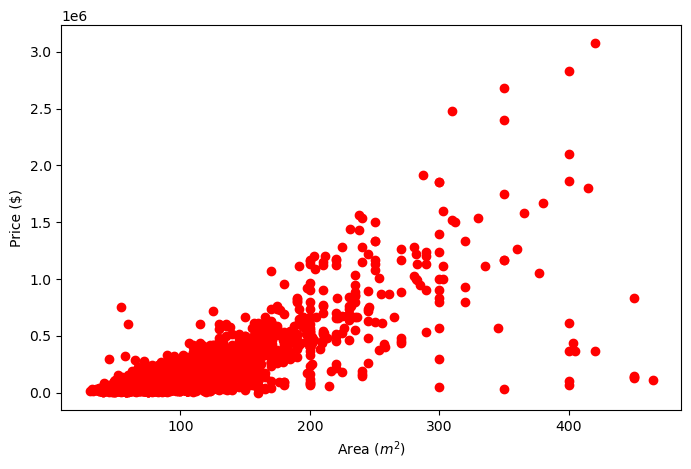

In [253]:
plt.figure(figsize=(8,5))
x_data, y_data = (cdf["Area"].values, cdf["Price(USD)"].values)
plt.plot(x_data, y_data, 'ro')
plt.ylabel('Price ($)')
plt.xlabel('Area $(m^2)$')
plt.show()

In [312]:
#normalizing the data
xdata =x_data/max(x_data)
ydata = y_data/max(y_data)

In [314]:
#defining the regression function
def sigmoid(x, Beta_1, Beta_2):
     y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
     return y

In [316]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(sigmoid, xdata, ydata)
#the final parameters
print(" beta_1 = %f, beta_2 = %f" % (popt[0], popt[1]))

 beta_1 = 4.649908, beta_2 = 0.837077


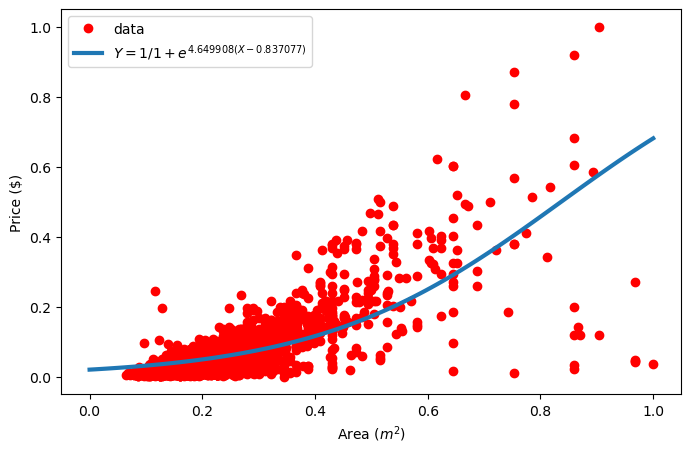

In [310]:
x = np.linspace(0, 500, 100)
x = x/max(x)
plt.figure(figsize=(8,5))
y = sigmoid(x, *popt)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x,y, linewidth=3.0, label="$Y = 1/{1+e^{%f(X-%f)}}$" % (popt[0], popt[1]))
plt.legend(loc='best')
plt.ylabel('Price ($)')
plt.xlabel('Area $(m^2)$')
plt.show()

In [324]:
Area = int(input('Enter an Area sq: '))
print("Prediction: ", "{:.2e}".format(sigmoid(Area/max(x_data), *popt)*max(y_data)))

Enter an Area sq:  200


Prediction:  4.03e+05


In [395]:
#accuracy test
msk = np.random.rand(len(cdf)) < 0.8
train_x = xdata[msk]
test_x = xdata[~msk]
train_y = ydata[msk]
test_y = ydata[~msk]

# build the model using train set
popt, pcov = curve_fit(sigmoid, train_x, train_y)

# predict using test set
y_hat = sigmoid(test_x, *popt)

# evaluation
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - test_y) ** 2))
# from sklearn.metrics import r2_score
# print("R2-score: %.2f" % r2_score(y_hat, test_y) )

Mean absolute error: 0.03
Residual sum of squares (MSE): 0.00
